# EDA del dataset de shakespiere

Este jupyter notebook tiene como objetivo realizar el EDA del dataset destinado para el primer taller, para ello tendremos encuenta los siguientes ojetivos:

**0. Scripts de librerias, carga de los datos y visualizacion primaria**
* Librerias

* Carga y visualizacion primaria de los datos

**1. Estadísticas Básicas de Volumen**
* Conteo de caracteres y palabras

* Tamaño del vocabulario bruto

**2. Análisis de Longitudes de Secuencias** 
* Distribución de longitudes

* Métricas clave

**3. Frecuencia de Palabras y N-gramas (Zipf's Law)**
* Palabras más comunes

* Filtro de palabras vacías

* Bigramas y Trigramas

**4. Análisis a Nivel de Caracteres**
* Variedad de caracteres

## 0. Scripts de librerias, carga de los datos y visualizacion primaria

### Librerias

Estas seran las librerias involucradas en el proceso de analisis del dataset.

In [2]:
%pip install pandas numpy nltk matplotlib

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter

# Descargas de NLTK para procesamiento de texto
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marlon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Marlon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Carga y visualizacion primaria de los datos

In [4]:
# primera vizualización de los datos
df = pd.read_csv('../data/raw/shakespeare.csv', index_col=0)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (4226158, 2)


,x,y
character_id,,
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"You sad Andronici, have done with woes; Give s...",a
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"ou sad Andronici, have done with woes; Give se...",t
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"u sad Andronici, have done with woes; Give sen...",
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"sad Andronici, have done with woes; Give sent...",h
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"sad Andronici, have done with woes; Give sente...",a


### Calidad de los datos

In [34]:
#Verificación de nulos, duplicados y ventanas de texto con múltiples objetivos (contradicciones).
null_count = df.isnull().sum().sum()
duplicates = df['x'].duplicated().sum()

# Celdas Vacías
empty_cells = (df['x'].str.strip() == "").sum()

# Ventanas contradictorias (mismo contexto 'x' con diferentes 'y')
targets_per_window = df.groupby("x")["y"].nunique()
conflicting_windows = (targets_per_window > 1).sum()

print("--- REPORTE DE CALIDAD DE DATOS ---")
print(f"Valores nulos totales          : {null_count}")
print(f"Celdas vacías en la columna de texto: {empty_cells} ({ (empty_cells/len(df))*100:.2f}%)")
print(f"Filas duplicadas exactas       : {duplicates:,} ({duplicates / len(df):.4%})")
print(f"Ventanas con múltiples targets : {conflicting_windows:,}")
print(f"Porcentaje de usabilidad real  : {((len(df) - duplicates) / len(df)):.4%}")

--- REPORTE DE CALIDAD DE DATOS ---
Valores nulos totales          : 0
Celdas vacías en la columna de texto: 0 (0.00%)
Filas duplicadas exactas       : 1,836 (0.0434%)
Ventanas con múltiples targets : 12
Porcentaje de usabilidad real  : 99.9566%


## 1. Estadisticas basicas de volumen

### Creacion de metricas clave

In [6]:
#Conteo de caracteres en cada fila con espacios
df['x_len'] = df['x'].apply(lambda x: len(x))

#Conteo de caracteres en cada fila sin espacios
df['x_len_no_spaces'] = df['x'].apply(lambda x: len(x.strip().replace(' ','')))

# Conteo de palabras en cada fila
df['x_words'] = df['x'].str.lower().str.findall(r'\w+')
df['x_word_count'] = df['x_words'].str.len()

# longitud promedio de las palabras por texto
df['avg_word_len'] = df['x_words'].apply(lambda x: np.mean([len(word) for word in x]) if len(x) > 0 else 0)

In [7]:
df[['avg_word_len', 'x_len', 'x_word_count', 'x_len_no_spaces']].head(1000)

,avg_word_len,x_len,x_word_count,x_len_no_spaces
character_id,,,,
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,4.642857,80,14,67
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,4.642857,80,14,67
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,4.642857,80,14,67
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,4.923077,80,13,66
THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,4.642857,80,14,67
...,...,...,...,...
THE_TRAGEDY_OF_TITUS_ANDRONICUS_LUCIUS,4.066667,80,15,65
THE_TRAGEDY_OF_TITUS_ANDRONICUS_LUCIUS,3.875000,80,16,66
THE_TRAGEDY_OF_TITUS_ANDRONICUS_LUCIUS,3.875000,80,16,66


### Visualizacion de las metricas obtenidas

<Axes: title={'center': 'Distribución de la longitud de los textos'}, xlabel='Longitud del texto', ylabel='Frecuencia'>

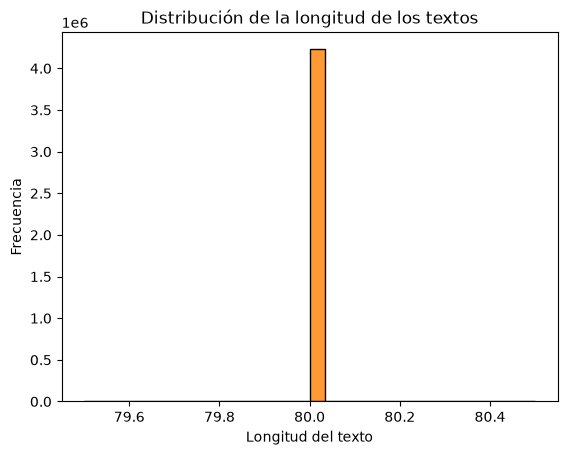

In [8]:
#Histograma de longitud de x en cada fila

df["x_len"].plot.hist(
    bins=30,  
    color="#ff9933",  
    edgecolor="black",  
    title="Distribución de la longitud de los textos",
    xlabel="Longitud del texto",
    ylabel="Frecuencia",  
)


<Axes: title={'center': 'Distribución de la cantidad de palabras por texto'}, xlabel='Cantidad de palabras', ylabel='Frecuencia'>

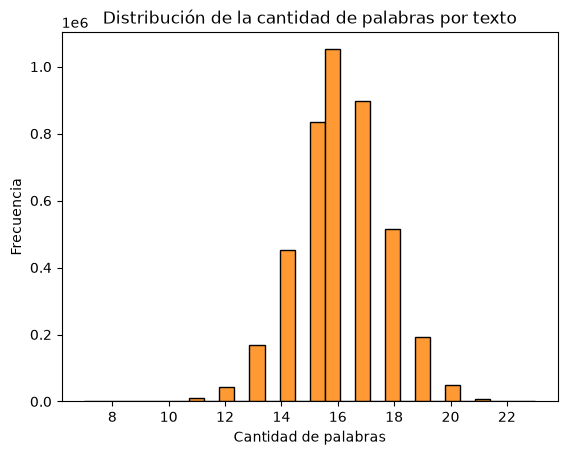

In [9]:
#Histograma de la cantidad de palabras en cada texto de x
df["x_word_count"].plot.hist(
    bins=30,  
    color="#ff9933",  
    edgecolor="black",  
    title="Distribución de la cantidad de palabras por texto",
    xlabel="Cantidad de palabras",
    ylabel="Frecuencia",  
)

<Axes: title={'center': 'Distribución longitud promedio de las palabras por texto'}, xlabel='longitud de palabras', ylabel='Frecuencia'>

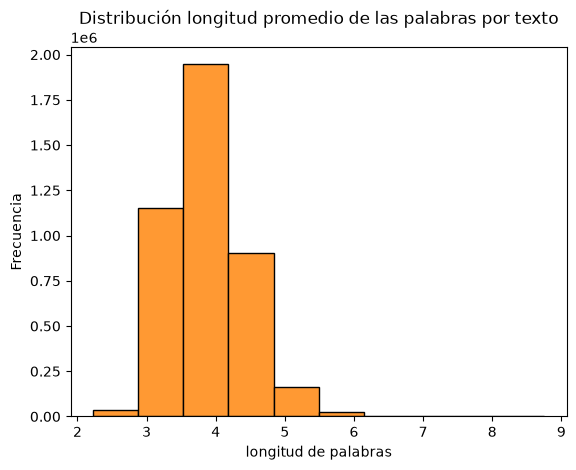

In [10]:
#Histograma de la longitud promedio de las palabras por texto en x
df['avg_word_len'].plot.hist(
    bins=10,  
    color="#ff9933",  
    edgecolor="black",  
    title="Distribución longitud promedio de las palabras por texto",
    xlabel="longitud de palabras",
    ylabel="Frecuencia",
)

### Resumen de los estadisticos obtenidos

In [11]:
stats = df[['avg_word_len', 'x_len', 'x_word_count', 'x_len_no_spaces']].describe(percentiles=[.25, .5, .75, .95, .99])
print(stats)

       avg_word_len      x_len  x_word_count  x_len_no_spaces
count  4.226158e+06  4226158.0  4.226158e+06     4.226158e+06
mean   3.865531e+00       80.0  1.606144e+01     6.501376e+01
std    5.057763e-01        0.0  1.606951e+00     1.609318e+00
min    2.227273e+00       80.0  7.000000e+00     4.800000e+01
25%    3.529412e+00       80.0  1.500000e+01     6.400000e+01
50%    3.812500e+00       80.0  1.600000e+01     6.500000e+01
75%    4.200000e+00       80.0  1.700000e+01     6.600000e+01
95%    4.714286e+00       80.0  1.900000e+01     6.800000e+01
99%    5.333333e+00       80.0  2.000000e+01     6.900000e+01
max    8.750000e+00       80.0  2.300000e+01     7.700000e+01


## Analisis del vocabulario y riqueza lexica

In [12]:
# Unión de todos los textos en x
full_text = ' '.join(df['x'].tolist())
tokens_raw = full_text.split()

# Limpieza para obtener vocavulario limpio

clean_text = re.sub(r'[^a-zA-Z\s]', '', full_text.lower())
tokens_clean = clean_text.split()

vocab_raw_size = len(set(tokens_raw))
vocab_clean_size = len(set(tokens_clean))
ttr = vocab_clean_size / len(tokens_clean)

print(f"Tamaño del vocabulario (sin limpiar): {vocab_raw_size}")
print(f"Tamaño del vocabulario (limpio): {vocab_clean_size}")
print(f"TTR (Type-Token Ratio): {ttr:.4f}")

Tamaño del vocabulario (sin limpiar): 257052
Tamaño del vocabulario (limpio): 122493
TTR (Type-Token Ratio): 0.0019


<Axes: title={'center': 'Top 20 palabras mas comunes en los textos'}, xlabel='Word', ylabel='Frequency'>

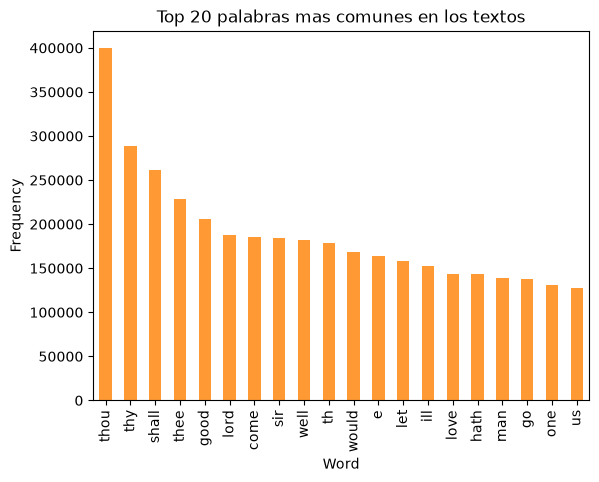

In [35]:
# Ley de Zipf
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens_clean if word not in stop_words]
word_counts = Counter(filtered_words).most_common(20)
df_words = pd.DataFrame(word_counts, columns=['Word', 'Frequency'])
df_words.set_index('Word')['Frequency'].plot.bar(
    xlabel='Word', 
    ylabel='Frequency', 
    color = "#ff9933", 
    title="Top 20 palabras mas comunes en los textos",
)



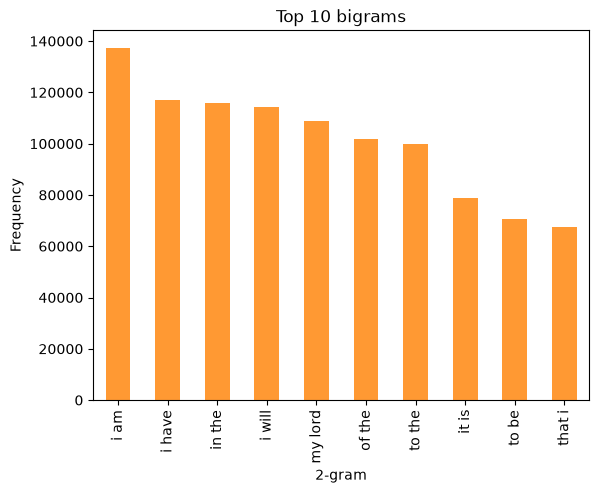

In [29]:
# Analisis de N-gramas
def plot_ngrams(tokens, n, title):
    n_grams = ngrams(tokens,n)
    counts = Counter(n_grams).most_common(10)
    df_ng = pd.DataFrame(counts, columns=['Gram', 'Frequency'])
    df_ng['Gram'] = df_ng['Gram'].apply(lambda x: ' '.join(x))
    df_ng.set_index('Gram')['Frequency'].plot.bar(
        xlabel = f"{n}-gram",
        ylabel= "Frequency",
        color = "#ff9933",
        title = title,
    )

plot_ngrams(tokens_clean, 2, "Top 10 bigrams")

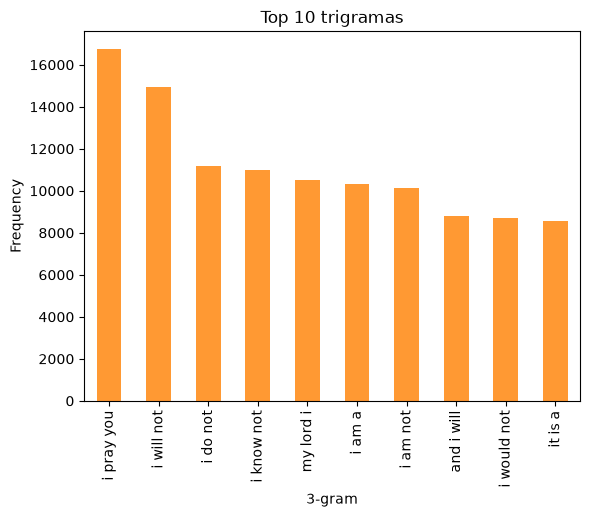

In [31]:
plot_ngrams(tokens_clean, 3, "Top 10 trigramas")

## Patrones y segos de los datos

Top 10 Caracteres Iniciales:
 x
     791334
e    375263
t    270196
o    262796
a    227540
h    205224
s    200960
n    199414
r    192984
i    185013
Name: count, dtype: int64

Top 10 Caracteres Finales:
 x
     790967
e    375141
t    270315
o    262246
a    227198
h    204827
s    200726
n    199758
r    192687
i    185099
Name: count, dtype: int64

Total de caracteres no-ASCII: 0


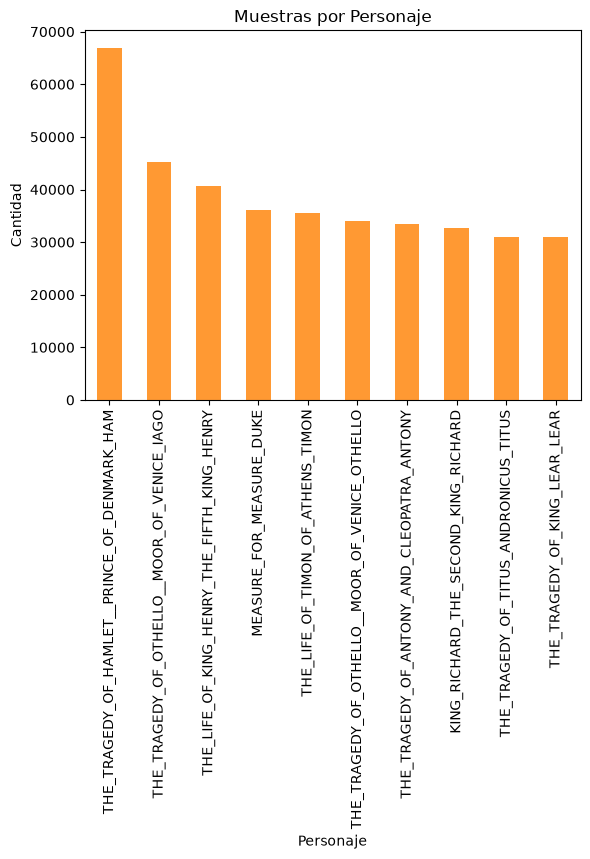

In [33]:
# Distribución por personaje
df.index.value_counts().head(10).plot.bar(
    title="Muestras por Personaje", 
    xlabel="Personaje", 
    ylabel="Cantidad",
    color="#ff9933"
    )

# Caracteres iniciales y finales
print("Top 10 Caracteres Iniciales:\n", df['x'].str[0].value_counts().head(10))
print("\nTop 10 Caracteres Finales:\n", df['x'].str[-1].value_counts().head(10))

# Anomalías de codificación (No ASCII)
anomalies = df['x'].apply(lambda x: len(re.findall(r'[^\x00-\x7F]', x))).sum()
print(f"\nTotal de caracteres no-ASCII: {anomalies}")